In [1]:
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import constants as const
from scipy.optimize import curve_fit

%matplotlib inline 

## Utilities

### Parser to Read File Format

In [2]:
COLUMNS: list[str] = ["E_meV", "lambda_nm", "photocurrent_A", "theta_deg"]

HEADER_MARKER: str = "E[meV]"


def read_spectrum(filepath: str | Path) -> pd.DataFrame:
    """Read a DLTS photo current spectrum into a DataFrame.

    The measurement files start with a metadata block of varying length, followed by a
    column header line and whitespace-aligned data columns. Both the header position and
    the column widths differ between files, so the header line is located by its marker
    and the data is split on runs of whitespace.

    Returns a DataFrame with the columns E_meV, lambda_nm, photocurrent_A and theta_deg.
    """
    filepath = Path(filepath)

    with filepath.open(encoding="latin-1") as file:
        for index, line in enumerate(file):
            if line.lstrip().startswith(HEADER_MARKER):
                header_index = index
                break
        else:
            raise ValueError(f"No column header starting with '{HEADER_MARKER}' found in '{filepath}'.")

    df: pd.DataFrame = pd.read_csv(
        filepath,
        skiprows=header_index + 1,
        sep=r"\s+",
        names=COLUMNS,
        encoding="latin-1",
        skip_blank_lines=True,
    )

    # append wavelength in nanometer
    df["wavelength"] = const.h * const.c / (df["E_meV"] / 1000 * const.e) * 1e9

    return df


### Matplotlib Config

In [3]:
PT_TO_INCHES = 1.0 / 72.27
BASE_FONT_SIZE = 10

LATEX_PREAMBLE = r"\usepackage{siunitx}"

# The preamble is read when a figure is drawn, not when its artists are created, and the
# inline backend draws the figure after the rc_context below has already exited. Setting
# it globally is what makes \unit{} survive until draw time; every other rcParam in the
# style dicts is baked into the artists inside the context and needs no global default.
plt.rcParams["text.latex.preamble"] = LATEX_PREAMBLE


SINGLE_COLUMN = {
    # Figure Geometry
    "figure.figsize": (221 * PT_TO_INCHES, 221 * PT_TO_INCHES),
    # Font Configuration
    "font.size": BASE_FONT_SIZE,
    "text.usetex": True,
    "text.latex.preamble": LATEX_PREAMBLE,
    "font.family": "serif",
    "font.serif": [
        "Computer Modern Roman",
        "Times New Roman",
        "Times",
        "Liberation Serif",
    ],
}

DOUBLE_COLUMN = {
    # Figure Geometry
    "figure.figsize": (452 * PT_TO_INCHES, 250 * PT_TO_INCHES),
    # Font Configuration
    "font.size": BASE_FONT_SIZE,
    "text.usetex": True,
    "text.latex.preamble": LATEX_PREAMBLE,
    "font.family": "serif",
    "font.serif": [
        "Computer Modern Roman",
        "Times New Roman",
        "Times",
        "Liberation Serif",
    ],
}

DATA_FOLDER = Path.cwd().parent / "data"
PLOT_FOLDER = Path.cwd().parent / "plots"
PLOT_FOLDER.mkdir(exist_ok=True)
TABLE_FOLDER = Path.cwd().parent / "tables"
TABLE_FOLDER.mkdir(exist_ok=True)


## Diode Current Spectrum

### Import Data

In [4]:
diode_folder: Path = DATA_FOLDER / "diodes"

diodes: list = []
for i, file in enumerate(sorted(diode_folder.glob("*.txt"))):
    df: pd.DataFrame = read_spectrum(file)
    diodes.append({"name": f"Diode {i + 1}", "df": df})


### Enrich Data

In [5]:
for diode in diodes:
    index = diode["df"]["photocurrent_A"].idxmax()
    diode["lambda_max"] = round(diode["df"]["wavelength"][index])
    diode["photocurrent_max"] = diode["df"]["photocurrent_A"][index]

### Plot Data

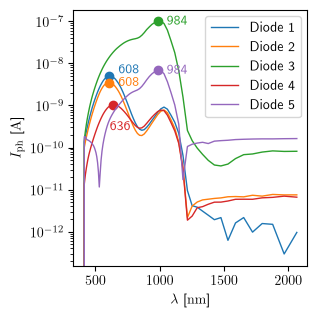

In [6]:
with plt.rc_context(SINGLE_COLUMN):
    fig, ax = plt.subplots(layout="constrained")

    for i, diode in enumerate(diodes):
        (line,) = ax.plot(diode["df"]["wavelength"], diode["df"]["photocurrent_A"], linewidth=1.0, label=diode["name"])
        color = line.get_color()
        ax.scatter(diode["lambda_max"], diode["photocurrent_max"], color=color)

        offset_y: int
        offset_x: int
        match i:
            case 0:
                offset_y = 0.4 * diode["photocurrent_max"]
                offset_x = 70
            case 3:
                offset_y = -0.7 * diode["photocurrent_max"]
                offset_x = -25
            case _:
                offset_y = 0
                offset_x = 70
        ax.text(
            x=diode["lambda_max"] + offset_x,
            y=diode["photocurrent_max"] + offset_y,
            s=diode["lambda_max"],
            ha="left",
            va="center",
            color=color,
        )
        ax.legend()

    ax.set_yscale("log")
    ax.set_xlabel(r"$\lambda$ [\unit{\nano\meter}]")
    ax.set_ylabel(r"$I_\mathrm{ph}$ [\unit{\ampere}]")

    fig.savefig(PLOT_FOLDER / "photocurrent.pdf")

## Reference Spectra

### Import Data

In [7]:
detector: Path = DATA_FOLDER / "detector"
detector_beginning: pd.DataFrame = read_spectrum(detector / "spectrum_beginning.txt")
detector_end: pd.DataFrame = read_spectrum(detector / "spectrum_ending.txt")

### Enrich Data
- The detector output is labeled as current, while it indicates a voltage
- The detector has a conversion factor $2000 \text{ V/W}$

In [8]:
conversion_factor = 2000  # V / W

detector_beginning["power"] = detector_beginning["photocurrent_A"] / conversion_factor
detector_end["power"] = detector_end["photocurrent_A"] / conversion_factor

detector_average: pd.Series = (detector_beginning["power"] + detector_end["power"]) / 2

reference_spread = (detector_end["power"] - detector_beginning["power"]).abs() / detector_average
reliable: pd.Series = detector_beginning["wavelength"] > 550 

### Plot Data

In [9]:
def plot_reference_spectra(ax: plt.Axes) -> None:
    """Draw the two detector reference spectra and their average onto ax."""
    ax.plot(
        detector_beginning["wavelength"],
        detector_beginning["power"],
        linewidth=1.0,
        label="Start of experiment",
    )
    ax.plot(detector_end["wavelength"], detector_end["power"], linewidth=1.0, label="End of experiment")
    ax.plot(detector_end["wavelength"], detector_average, linewidth=1.0, linestyle="--", alpha=0.7, label="Average")
    ax.legend()

    ax.set_xlabel(r"$\lambda$ [\unit{\nano\meter}]")
    ax.set_ylabel(r"$P_\mathrm{opt}$ [\unit{\watt}]")


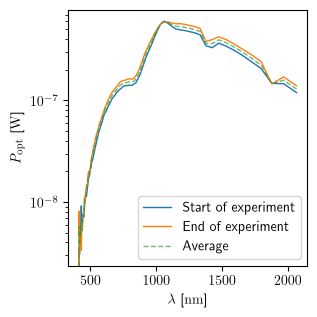

In [10]:
with plt.rc_context(SINGLE_COLUMN):
    fig, ax = plt.subplots(layout="constrained")
    plot_reference_spectra(ax)

    ax.set_yscale("log")

    fig.savefig(PLOT_FOLDER / "reference_spectra_log.pdf")

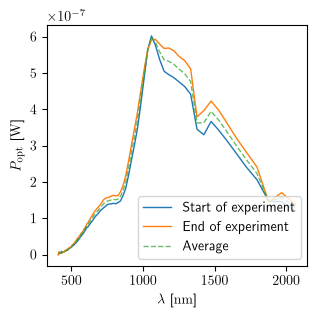

In [11]:
with plt.rc_context(SINGLE_COLUMN):
    fig, ax = plt.subplots(layout="constrained")
    plot_reference_spectra(ax)

    fig.savefig(PLOT_FOLDER / "reference_spectra.pdf")

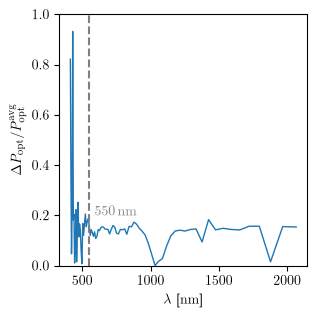

In [12]:
with plt.rc_context(SINGLE_COLUMN):
    fig, ax = plt.subplots(layout="constrained")
    ax.plot(
        detector_beginning["wavelength"],
        reference_spread,
        linewidth=1.0,
    )
    ax.set_xlabel(r"$\lambda$ [\unit{\nano\meter}]")
    ax.set_ylabel(r"$\Delta P_\mathrm{opt}/P_\mathrm{opt}^{\mathrm{avg}}$")
    ax.set_ylim(0,1)

    ax.vlines(x=550, ymin=0, ymax=1, color="gray", linestyles="--")
    ax.text(x=590, y=0.2, s=r"\qty{550}{\nano\meter}", color="gray")

    fig.savefig(PLOT_FOLDER / "reference_spread.pdf")
    

## Spectral Responsivity & Quantum Efficiency

### Import Data

In [13]:
normalized_diodes = deepcopy(diodes)

### Enrich Data

In [14]:
pre = const.h * const.c / const.e * 1e9

for diode in normalized_diodes:
    df = diode["df"]
    df["responsivity"] = df["photocurrent_A"] / detector_average


    df["quantum_efficiency"] = pre * df["responsivity"] / df["wavelength"]
    df["quantum_efficiency_percent"] = df["quantum_efficiency"] * 100

In [15]:
# parameters for lambda max
for diode in normalized_diodes:
    old_index = diode["df"]["photocurrent_A"][reliable].idxmax()
    index = diode["df"]["responsivity"][reliable].idxmax()

    diode["lambda_max_new"] = round(diode["df"]["wavelength"][index])
    diode["responsivity_max_old"] = diode["df"]["responsivity"][old_index]
    diode["responsivity_max_new"] = diode["df"]["responsivity"][index]
    diode["quantum_percent_max"] = diode["df"]["quantum_efficiency_percent"][index]

In [16]:
# parameters for lambda = 550nm
lambda_specified = 550

for diode in normalized_diodes:
    index = (diode["df"]["wavelength"] - lambda_specified).abs().idxmin()
    diode["lambda_specified"] = lambda_specified
    diode["responsivity_specified"] = diode["df"]["responsivity"][index]
    diode["quantum_percent_specified"] = diode["df"]["quantum_efficiency_percent"][index]

### Plot Data

#### Spectral Responsivity

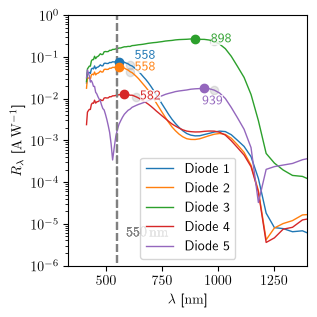

In [41]:
with plt.rc_context(SINGLE_COLUMN):
    fig, ax = plt.subplots(layout="constrained")

    for i, diode in enumerate(normalized_diodes):
        (line,) = ax.plot(diode["df"]["wavelength"], diode["df"]["responsivity"], linewidth=1.0, label=diode["name"])
        color = line.get_color()
        ax.scatter(diode["lambda_max"], diode["responsivity_max_old"], color="gray", alpha=0.2)
        ax.scatter(diode["lambda_max_new"], diode["responsivity_max_new"], color=color, zorder=10)

        ax.vlines(x=550, ymin=0, ymax=10, color="gray", linestyles="--")
        ax.text(x=590, y=5e-6, s=r"\qty{550}{\nano\meter}", color="gray")

        offset_y: int
        offset_x: int
        match i:
            case 0:
                offset_y = 0.4 * diode["responsivity_max_new"]
                offset_x = 70
            case 3:
                offset_y = -0.1 * diode["responsivity_max_new"]
                offset_x = 70
            case 4:
                offset_y = -0.5 * diode["responsivity_max_new"]
                offset_x = -10
            case _:
                offset_y = 0
                offset_x = 70

        ax.text(
            x=diode["lambda_max_new"] + offset_x,
            y=diode["responsivity_max_new"] + offset_y,
            s=diode["lambda_max_new"],
            ha="left",
            va="center",
            color=color,
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 0, "alpha": 0.8},
        )
        ax.legend()


    ax.set_ylim(bottom=1e-6, top=1)
    ax.set_xlim(right=1400)
    ax.set_yscale("log")
    ax.set_xlabel(r"$\lambda$ [\unit{\nano\meter}]")
    ax.set_ylabel(r"$R_\lambda$ [\unit{\ampere\per\watt}]")

    fig.savefig(PLOT_FOLDER / "responsivity.pdf")

#### Quantum Efficiency

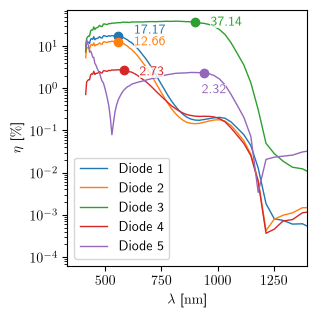

In [43]:
with plt.rc_context(SINGLE_COLUMN):
    fig, ax = plt.subplots(layout="constrained")

    for i, diode in enumerate(normalized_diodes):
        (line,) = ax.plot(
            diode["df"]["wavelength"],
            diode["df"]["quantum_efficiency_percent"],
            linewidth=1.0,
            label=diode["name"],
        )
        color = line.get_color()
        ax.scatter(diode["lambda_max_new"], diode["quantum_percent_max"], color=color)

        offset_y: int
        offset_x: int
        match i:
            case 0:
                offset_y = 0.4 * diode["quantum_percent_max"]
                offset_x = 70
            case 3:
                offset_y = -0.1 * diode["quantum_percent_max"]
                offset_x = 70
            case 4:
                offset_y = -0.6 * diode["quantum_percent_max"]
                offset_x = -10
            case _:
                offset_y = 0
                offset_x = 70

        ax.text(
            x=diode["lambda_max_new"] + offset_x,
            y=diode["quantum_percent_max"] + offset_y,
            s=f"{diode['quantum_percent_max']:.2f}",
            ha="left",
            va="center",
            color=color,
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 0, "alpha": 0.8},
        )
        ax.legend()

    ax.set_xlim(right=1400)
    ax.set_yscale("log")
    ax.set_xlabel(r"$\lambda$ [\unit{\nano\meter}]")
    ax.set_ylabel(r"$\eta$ [\unit{\percent}]")

    fig.savefig(PLOT_FOLDER / "quantum_efficiency.pdf")

#### Table

In [19]:
table_data = deepcopy(normalized_diodes)
for data in table_data:
    data.pop("df")
    data.pop("lambda_max")
    data.pop("photocurrent_max")
    data.pop("responsivity_max_old")
    data["lambda_max"] = data.pop("lambda_max_new")
    data["responsivity_max"] = data.pop("responsivity_max_new")

diode_table = pd.DataFrame(table_data)

In [20]:
columns_ordered = [
    "name",
    "lambda_max",
    "responsivity_max",
    "quantum_percent_max",
    "lambda_specified",
    "responsivity_specified",
    "quantum_percent_specified",
]
display(diode_table[columns_ordered])

,name,lambda_max,responsivity_max,quantum_percent_max,lambda_specified,responsivity_specified,quantum_percent_specified
0,Diode 1,558,0.077354,17.172617,550,0.076685,17.254031
1,Diode 2,558,0.057037,12.662151,550,0.056677,12.752314
2,Diode 3,898,0.269159,37.143916,550,0.158539,35.671253
3,Diode 4,582,0.012837,2.734215,550,0.012138,2.731031
4,Diode 5,939,0.017560,2.317962,550,0.001818,0.409147


In [21]:
# LaTeX export of the table above. The keys select and order the exported columns, the
# values are the header cells; the unit is forced onto a second line so the table fits
# into the text width. lambda_specified is dropped, it is stated in the two headers.
COLUMN_LABELS = {
    "name": "{}",
    "lambda_max": r"{\CellWithForceBreak{$\lambda_\mathrm{max}$\\{}[\unit{\nano\meter}]}}",
    "responsivity_max": r"{\CellWithForceBreak{$R_{\lambda_\mathrm{max}}$\\{}[\unit{\ampere\per\watt}]}}",
    "quantum_percent_max": r"{\CellWithForceBreak{$\eta(\lambda_\mathrm{max})$\\{}[\unit{\percent}]}}",
    "responsivity_specified": r"{\CellWithForceBreak{$R_{\qty{550}{\nano\meter}}$\\{}[\unit{\ampere\per\watt}]}}",
    "quantum_percent_specified": r"{\CellWithForceBreak{$\eta(\qty{550}{\nano\meter})$\\{}[\unit{\percent}]}}",
}

COLUMN_FORMATS = {
    "lambda_max": "{:.0f}",
    "responsivity_max": "{:.4f}",
    "quantum_percent_max": "{:.2f}",
    "responsivity_specified": "{:.4f}",
    "quantum_percent_specified": "{:.2f}",
}

latex_table = diode_table[list(COLUMN_LABELS)].copy()
for column, number_format in COLUMN_FORMATS.items():
    latex_table[column] = latex_table[column].map(number_format.format)

latex = latex_table.rename(columns=COLUMN_LABELS).to_latex(
    index=False,
    escape=False,
    column_format="l" + "S" * len(COLUMN_FORMATS),
)

(TABLE_FOLDER / "diode_table.tex").write_text(latex)
print(latex)


\begin{tabular}{lSSSSS}
\toprule
{} & {\CellWithForceBreak{$\lambda_\mathrm{max}$\\{}[\unit{\nano\meter}]}} & {\CellWithForceBreak{$R_{\lambda_\mathrm{max}}$\\{}[\unit{\ampere\per\watt}]}} & {\CellWithForceBreak{$\eta(\lambda_\mathrm{max})$\\{}[\unit{\percent}]}} & {\CellWithForceBreak{$R_{\qty{550}{\nano\meter}}$\\{}[\unit{\ampere\per\watt}]}} & {\CellWithForceBreak{$\eta(\qty{550}{\nano\meter})$\\{}[\unit{\percent}]}} \\
\midrule
Diode 1 & 558 & 0.0774 & 17.17 & 0.0767 & 17.25 \\
Diode 2 & 558 & 0.0570 & 12.66 & 0.0567 & 12.75 \\
Diode 3 & 898 & 0.2692 & 37.14 & 0.1585 & 35.67 \\
Diode 4 & 582 & 0.0128 & 2.73 & 0.0121 & 2.73 \\
Diode 5 & 939 & 0.0176 & 2.32 & 0.0018 & 0.41 \\
\bottomrule
\end{tabular}



## Photodiode Detector Linearity

### Import Data

In [22]:
linearity_folder = DATA_FOLDER / "linearity"

linearity_diodes: list = [
    {"name": "Diode 4", "df": pd.read_csv(linearity_folder / "D4_1.6mm.csv")},
    {"name": "Diode 5", "df": pd.read_csv(linearity_folder / "D5_0.75mm.csv")},
]

In [23]:
for diode in linearity_diodes:
    print(diode["name"])
    display(diode["df"])

Diode 4


,d,I
0,0.00,8.400000e-07
1,0.15,5.800000e-07
2,0.30,4.000000e-07
3,0.60,1.900000e-07
4,1.30,4.300000e-08
5,2.00,1.140000e-08
6,2.60,3.300000e-09
7,3.00,9.600000e-10
8,3.30,8.100000e-10
9,3.60,4.300000e-10


Diode 5


,d,I
0,0.00,9.700000e-07
1,0.15,5.500000e-07
2,0.30,2.950000e-07
3,0.60,2.000000e-07
4,1.30,4.910000e-08
5,2.00,5.350000e-08
6,2.60,2.400000e-08
7,3.00,1.130000e-08
8,3.30,9.500000e-09
9,3.60,6.340000e-09


### Enrich Data

In [24]:
for diode in linearity_diodes:
    df = diode["df"]
    df["relative_intensity"] = 10 ** -df["d"]
    df["relative_current"] = df["I"] / df["I"][0]
    df["relative_intensity_log"] = np.log(df["relative_intensity"])
    df["relative_current_log"] = np.log(df["relative_current"])

### Fit Data

A straight line in the log-log plane, $\ln(I/I_0) = m \ln(P/P_0) + n$, corresponds to the power law $I/I_0 = e^n \, (P/P_0)^m$. An ideal, linear detector response gives $m = 1$.

In [25]:
def linear(x: np.ndarray, m: float, n: float) -> np.ndarray:
    """Straight line in the log-log plane, equivalent to I/I_0 = e^n * (P/P_0)^m."""
    return m * x + n


# Diode 4 follows a single power law over the whole range. Diode 5 leaves the linear regime
# between OD 1.3 and OD 2.0 and continues with a flatter slope, so it is fitted piecewise;
# splitting there minimizes the combined residual of the two segments.
SEGMENTS_OD: dict[str, list[tuple[float, float]]] = {
    "Diode 4": [(0.0, 5.0)],
    "Diode 5": [(0.0, 1.3), (2.0, 5.0)],
}

for diode in linearity_diodes:
    df = diode["df"]
    diode["fits"] = []

    for od_min, od_max in SEGMENTS_OD[diode["name"]]:
        mask = df["d"].between(od_min, od_max)
        parameters, covariance = curve_fit(
            linear,
            df["relative_intensity_log"][mask],
            df["relative_current_log"][mask],
        )
        m_error, n_error = np.sqrt(np.diag(covariance))

        diode["fits"].append(
            {
                "m": parameters[0],
                "n": parameters[1],
                "m_error": m_error,
                "n_error": n_error,
                "intensity_min": df["relative_intensity"][mask].min(),
                "intensity_max": df["relative_intensity"][mask].max(),
            }
        )

In [26]:
fit_table = pd.DataFrame(
    [
        {"name": diode["name"], "segment": i + 1} | fit
        for diode in linearity_diodes
        for i, fit in enumerate(diode["fits"])
    ]
)
display(fit_table)

,name,segment,m,n,m_error,n_error,intensity_min,intensity_max
0,Diode 4,1,0.920542,-0.108109,0.010342,0.071561,0.000010,1.00
1,Diode 5,1,0.943135,-0.243348,0.095815,0.145092,0.050119,1.00
2,Diode 5,2,0.619261,-0.028259,0.020460,0.175050,0.000010,0.01


### Plot Data

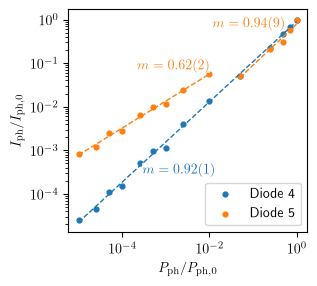

In [27]:
# relative intensity at which a slope label sits, and the factor by which it is offset from
# its fit line
LABEL_ANCHORS: dict[tuple[str, int], tuple[float, float]] = {
    ("Diode 4", 0): (2e-3, 0.12),
    ("Diode 5", 0): (0.08, 11.0),
    ("Diode 5", 1): (1.5e-3, 5.0),
}

with plt.rc_context(SINGLE_COLUMN):
    fig, ax = plt.subplots(layout="constrained")

    for diode in linearity_diodes:
        scatter = ax.scatter(
            diode["df"]["relative_intensity"],
            diode["df"]["relative_current"],
            s=12,
            label=diode["name"],
        )
        color = scatter.get_facecolor()[0]

        for i, fit in enumerate(diode["fits"]):
            intensity = np.logspace(np.log10(fit["intensity_min"]), np.log10(fit["intensity_max"]), 2)
            ax.plot(
                intensity,
                np.exp(fit["n"]) * intensity ** fit["m"],
                color=color,
                linewidth=1.0,
                linestyle="--",
            )

            x_text, y_factor = LABEL_ANCHORS[diode["name"], i]
            ax.text(
                x=x_text,
                y=y_factor * np.exp(fit["n"]) * x_text ** fit["m"],
                s=rf"$m = {fit['m']:.2f}({int(fit['m_error'] * 100)})$",
                ha="center",
                va="center",
                color=color,
                bbox={"facecolor": "white", "edgecolor": "none", "pad": 0, "alpha": 0.8},
            )

    ax.loglog()
    # equal aspect in log space: one decade covers the same length on both axes, so ideal
    # linearity shows up as a 45 degree line
    ax.set_aspect("equal")
    ax.legend(loc="lower right")

    ax.set_xlabel(r"$P_\mathrm{ph} / P_{\mathrm{ph},0}$")
    ax.set_ylabel(r"$I_\mathrm{ph} / I_{\mathrm{ph},0}$")

    fig.savefig(PLOT_FOLDER / "linearity.pdf")

## Human Eye Response

### Import Data

In [28]:
def read_human_response(filepath: str | Path) -> pd.DataFrame:
    raw: pd.DataFrame = pd.read_csv(
        filepath,
        sep="\t",
        skiprows=3,
        names=["wavelength_scotopic", "scotopic", "wavelength_photopic", "photopic"],
        encoding="utf-8-sig",  # the file starts with a byte order mark
    )

    if not raw["wavelength_scotopic"].equals(raw["wavelength_photopic"]):
        raise ValueError(f"The two curves in '{filepath}' are sampled on different wavelength grids.")

    return pd.DataFrame(
        {
            "wavelength": raw["wavelength_scotopic"],
            "scotopic": raw["scotopic"],
            "photopic": raw["photopic"],
        }
    )

In [29]:
human_eye: pd.DataFrame = read_human_response(DATA_FOLDER / "human_response_curve.dat")
diode_4: pd.DataFrame = normalized_diodes[3]["df"].copy()

### Enrich Data

In [30]:
diode_4["relative_responsivity"] = diode_4["responsivity"] / max(diode_4["responsivity"])

In [31]:
def peak_and_fwhm(wavelength: pd.Series, response: pd.Series) -> dict[str, float]:
    """Locate the maximum of a single-peaked curve and its full width at half maximum.

    The curves are sampled on coarse and, for the diode, unevenly spaced wavelength grids,
    so the peak is taken as the largest sample and both half-maximum crossings are linearly
    interpolated between the two samples that bracket them, walking outwards from the peak.
    """
    data = pd.DataFrame({"wavelength": wavelength, "response": response}).dropna().sort_values("wavelength")
    x = data["wavelength"].to_numpy()
    y = data["response"].to_numpy()

    peak = int(y.argmax())
    half = y[peak] / 2

    def crossing(indices: range) -> float:
        """Wavelength at which the curve first drops below half maximum along indices."""
        indices = list(indices)
        for previous, current in zip(indices, indices[1:]):
            if y[current] < half:
                return x[previous] + (half - y[previous]) * (x[current] - x[previous]) / (y[current] - y[previous])
        return np.nan

    left = crossing(range(peak, -1, -1))
    right = crossing(range(peak, len(x)))

    return {
        "lambda_peak": x[peak],
        "peak": y[peak],
        "lambda_half_left": left,
        "lambda_half_right": right,
        "fwhm": right - left,
    }

In [32]:
eye_curves: list[dict] = [
    {"name": "Scotopic", "wavelength": human_eye["wavelength"], "response": human_eye["scotopic"]},
    {"name": "Photopic", "wavelength": human_eye["wavelength"], "response": human_eye["photopic"]},
    {"name": "Diode 4", "wavelength": diode_4["wavelength"], "response": diode_4["relative_responsivity"]},
]

for curve in eye_curves:
    curve |= peak_and_fwhm(curve["wavelength"], curve["response"])

### Plot Data

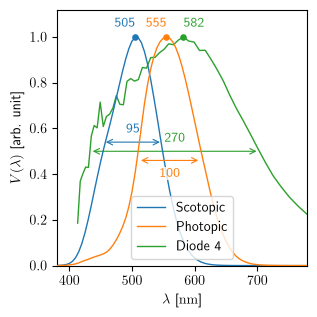

In [33]:
# The half-width arrows all belong at the half maximum, but drawn on the same line they would
# hide each other, so they are staggered slightly around it.
ARROW_Y: dict[str, float] = {"Scotopic": 0.54, "Photopic": 0.46, "Diode 4": 0.50}
# alignment of the peak label, and the vertical offset of the width label
LABELS: dict[str, tuple[str, float]] = {
    "Scotopic": ("right", 0.03),
    "Photopic": ("right", -0.03),
    "Diode 4": ("left", 0.03),
}
# the broad diode curve crosses both eye curves, so it is drawn underneath them
ZORDER: dict[str, int] = {"Diode 4": 1, "Scotopic": 2, "Photopic": 3}

with plt.rc_context(SINGLE_COLUMN):
    fig, ax = plt.subplots(layout="constrained")

    for curve in eye_curves:
        zorder = ZORDER[curve["name"]]
        (line,) = ax.plot(
            curve["wavelength"], curve["response"], linewidth=1.0, label=curve["name"], zorder=zorder
        )
        color = line.get_color()
        peak_ha, label_offset = LABELS[curve["name"]]
        arrow_y = ARROW_Y[curve["name"]]

        # maximum
        ax.scatter(curve["lambda_peak"], curve["peak"], color=color, s=14, zorder=zorder + 10)
        ax.text(
            x=curve["lambda_peak"],
            y=1.06,
            s=f"{curve['lambda_peak']:.0f}",
            ha=peak_ha,
            va="center",
            color=color,
        )

        # full width at half maximum
        ax.annotate(
            "",
            xy=(curve["lambda_half_left"], arrow_y),
            xytext=(curve["lambda_half_right"], arrow_y),
            arrowprops={"arrowstyle": "<->", "color": color, "linewidth": 0.8, "alpha": 1},
            zorder=zorder,
        )
        ax.text(
            x=(curve["lambda_half_left"] + curve["lambda_half_right"]) / 2,
            y=arrow_y + label_offset,
            s=f"{curve['fwhm']:.0f}",
            ha="center",
            va="bottom" if label_offset > 0 else "top",
            color=color,
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 0, "alpha": 0.8},
            zorder=zorder + 10,
        )

    ax.legend(loc="lower center")

    ax.set_xlim(min(human_eye["wavelength"]), max(human_eye["wavelength"]))
    ax.set_ylim(0, 1.12)

    ax.set_xlabel(r"$\lambda$ [\unit{\nano\meter}]")
    ax.set_ylabel(r"$V(\lambda)$ [arb. unit]")

    fig.savefig(PLOT_FOLDER / "human_eye.pdf")

#### Table

In [34]:
eye_table = pd.DataFrame(eye_curves).drop(columns=["wavelength", "response", "peak"])
display(eye_table)

,name,lambda_peak,lambda_half_left,lambda_half_right,fwhm
0,Scotopic,505.000000,453.793103,548.915663,95.122559
1,Photopic,555.000000,509.848873,610.240698,100.391825
2,Diode 4,582.085439,432.845490,703.271404,270.425914


## Chopper Frequency Dependence

### Import Data

In [35]:
chopper_dependence: pd.DataFrame = pd.read_csv(DATA_FOLDER / "chopper_dependence_0.3mm.csv")


### Enrich Data

In [36]:
colors = {1: "blue", 3: "green", 10: "orange"}


def apply_color(number: int):
    return colors[number]


In [37]:
def highpass(f, f_c, I_s):
    return I_s * f / np.sqrt(f**2 + f_c**2)

In [38]:
chopper_dependence["I_nA"] = chopper_dependence["I"] * 1e9
chopper_dependence["color"] = chopper_dependence["t"].apply(apply_color)

(f_c, I_s), _ = curve_fit(highpass, chopper_dependence["f"], chopper_dependence["I_nA"], [1, 125])
frequencies = np.linspace(1, 1e3, 10000)
print(f"Critical frequency: {f_c} Hertz")
print(f"Saturation current: {I_s} nA")

Critical frequency: 0.7737985834335449 Hertz
Saturation current: 124.92854862955704 nA


### Plot Data

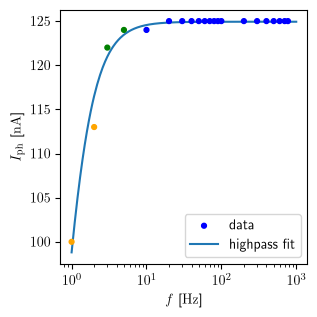

In [39]:
with plt.rc_context(SINGLE_COLUMN):
    fig, ax = plt.subplots(layout="constrained")

    ax.scatter(chopper_dependence["f"], chopper_dependence["I_nA"], color=chopper_dependence["color"], s=12, label="data")
    ax.plot(frequencies, highpass(frequencies, f_c, I_s), zorder=-1, label="highpass fit")

    ax.set_xscale("log")
    ax.set_xlabel(r"$f$ [\unit{\hertz}]")
    ax.set_ylabel(r"$I_\mathrm{ph}$ [\unit{\nano\ampere}]")
    ax.legend()

    fig.savefig(PLOT_FOLDER / "chopper.pdf")